### Signal Detection (PRR)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/doxorubicin_3000_faers.csv")

reaction_counts = df['Reaction'].value_counts()

signals = []

for reaction in reaction_counts.index:

    A = reaction_counts[reaction]

    B = len(df) - A

    C = 50   # placeholder for other drugs
    D = 500  # placeholder

    prr = (A/(A+B)) / (C/(C+D))

    chi_square = ((A*D - B*C)**2) * (A+B+C+D) / ((A+B)*(C+D)*(A+C)*(B+D))

    signals.append({
        "Reaction": reaction,
        "PRR": prr,
        "Chi_Square": chi_square
    })

signals_df = pd.DataFrame(signals)

signals_df = signals_df.sort_values("PRR", ascending=False)

signals_df.head(20)

,Reaction,PRR,Chi_Square
0,Death,1.081667,0.291991
1,Disease progression,0.627000,9.154582
2,Febrile neutropenia,0.568333,13.154489
3,Disease recurrence,0.234667,72.388600
4,Haematotoxicity,0.220000,77.833221
5,Neutropenia,0.212667,80.725284
6,Secondary immunodeficiency,0.168667,100.898277
7,B-cell lymphoma recurrent,0.143000,115.424224
8,Hepatitis B,0.128333,124.883666
9,Toxicity to various agents,0.117333,132.625623


#### Top Safety Signals

<Axes: title={'center': 'Top Pharmacovigilance Signals'}, xlabel='Reaction'>

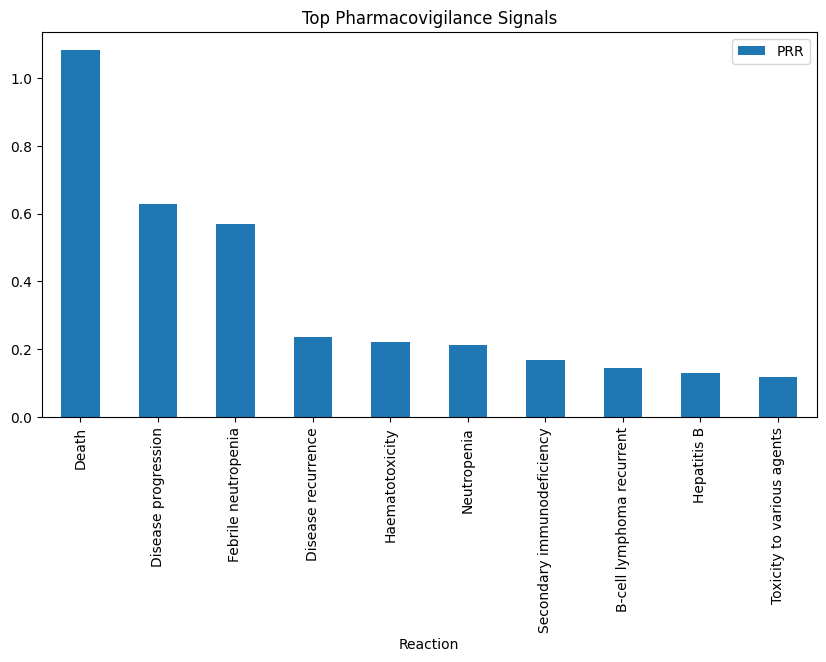

In [2]:
signals_df.head(10).plot(
    x="Reaction",
    y="PRR",
    kind="bar",
    figsize=(10,5),
    title="Top Pharmacovigilance Signals"
)

In [3]:
signals_df['is_signal'] = (
    (signals_df['PRR'] >= 2) &
    (signals_df['Chi_Square'] >= 4)
)

In [6]:
signals_df['is_signal'].value_counts()

is_signal
False    745
Name: count, dtype: int64

- After applying PRR ≥ 2 and Chi-square ≥ 4 thresholds, no ADR signals were detected. This indicates that although some adverse events are frequent, they are not disproportionately associated with DOXORUBICIN in this dataset